In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


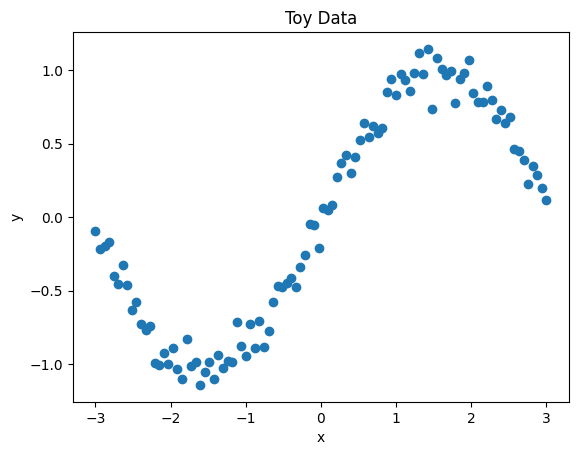

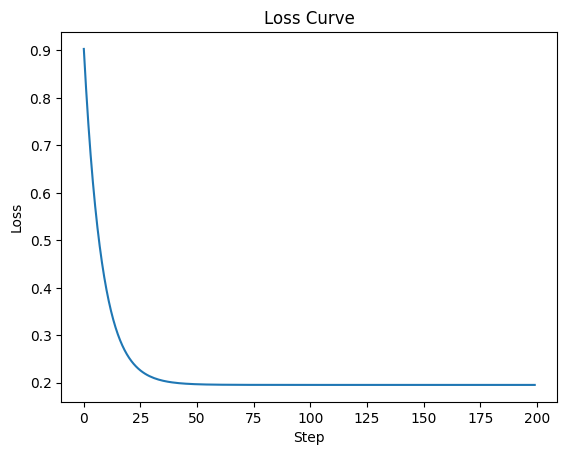

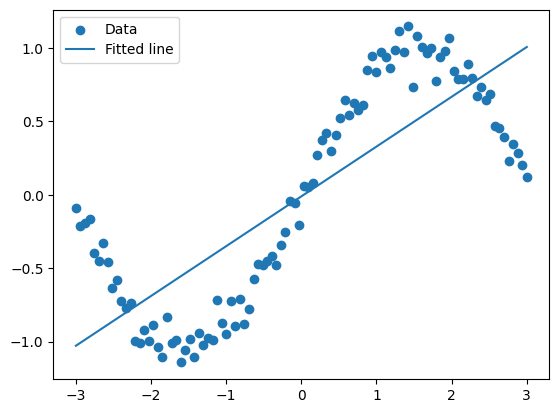

In [3]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.randn(100) * 0.1

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn()*0.1
b = np.random.randn()*0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# y_hat = w*x + b
# loss = np.mean((y_hat - y) ** 2) 
# dw = np.mean(2 * (y_hat - y) * x)
# db = np.mean(2 * (y_hat - y)) 
# w -= lr * dw
# b -= lr * db


lr = 0.01
steps = 200
losses = []

for step in range(steps):
    y_hat = w*x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db

    losses.append(loss)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Loss curve
plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()


# Data
y_pred = w*x + b

plt.scatter(x,y,label="Data")

plt.plot(x,y_pred,label="Fitted line")

plt.legend()
plt.show()

In [ ]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b1 = np.zeros(1)


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)



# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
